In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# KAGGLER BUILT-IN DEVICE SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
import os
import logging

# Suppress TensorFlow logging and warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/usr/local/cuda'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# 1. Define dataset path and hyperparameters
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

print("--- Starting Dataset Loading ---")

# 2. Load Training Dataset (80% data)
train_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 3. Load Validation Dataset (20% data)
val_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 4. Get and verify class names
class_names = train_ds.class_names
print("\nDetected Classes:", class_names)
print(f"Total Number of Classes: {len(class_names)}")

# 5. Verify data shapes
for images, labels in train_ds.take(1):
    print(f"\nImage batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    break

--- Starting Dataset Loading ---
Found 7153 files belonging to 4 classes.
Using 5723 files for training.
Found 7153 files belonging to 4 classes.
Using 1430 files for validation.

Detected Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total Number of Classes: 4

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 4)


In [5]:
import os
from pathlib import Path
from PIL import Image
from collections import Counter

# Define dataset path
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

print("--- Analyzing Dataset Information ---")

# 1. Get Class Names and Total Classes
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
total_classes = len(class_names)

# 2. Count Total Images and Images per Class
image_extensions = []
total_images = 0
class_distribution = {}

for class_name in class_names:
    class_dir = dataset_path / class_name
    # List all files in the class directory
    files = list(class_dir.glob('*'))
    
    # Filter only images and get extensions
    valid_images = [f for f in files if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    
    class_distribution[class_name] = len(valid_images)
    total_images += len(valid_images)
    
    for img_file in valid_images:
        image_extensions.append(img_file.suffix.lower())

# 3. Identify Unique Image Formats
image_format_counts = Counter(image_extensions)
unique_formats = [fmt.upper().replace('.', '') for fmt in image_format_counts.keys()]

# 4. Print Structured Output for Conference Paper
print("\n" + "="*40)
print("📌 DATASET SUMMARY")
print("="*40)
print(f"Total Images   : {total_images}")
print(f"Total Classes  : {total_classes}")
print(f"Class Names    : {class_names}")
print(f"Image Formats  : {', '.join(unique_formats)}")
print("-"*40)
print("📊 CLASS-WISE DISTRIBUTION:")
for class_name, count in class_distribution.items():
    percentage = (count / total_images) * 100
    print(f" - {class_name}: {count} images ({percentage:.2f}%)")
print("="*40)

--- Analyzing Dataset Information ---

📌 DATASET SUMMARY
Total Images   : 7153
Total Classes  : 4
Class Names    : ['glioma', 'meningioma', 'notumor', 'pituitary']
Image Formats  : JPG
----------------------------------------
📊 CLASS-WISE DISTRIBUTION:
 - glioma: 1621 images (22.66%)
 - meningioma: 1775 images (24.81%)
 - notumor: 2000 images (27.96%)
 - pituitary: 1757 images (24.56%)


**Random Dataset Sample Visualization Script**

--- Generating Random Dataset Samples for Visualization ---


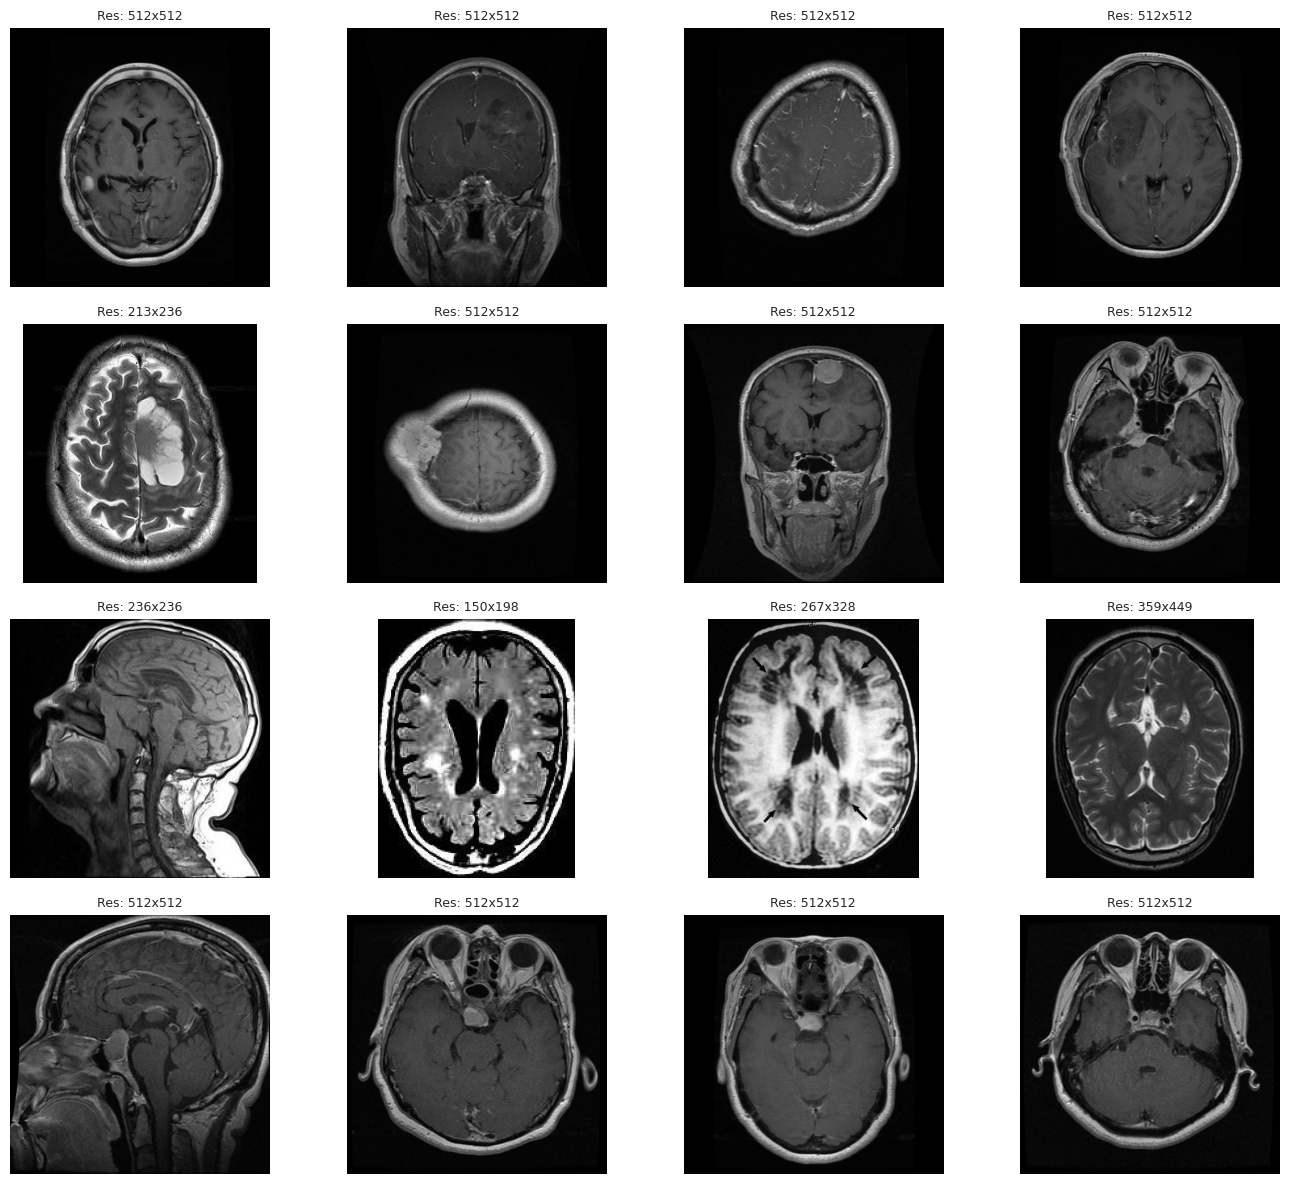


[SUCCESS] Random samples visualized and saved successfully as 'dataset_samples_grid.png'


In [8]:
import os
import random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Define dataset path
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

# Get sorted class names
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
num_classes = len(class_names)
samples_per_class = 4  # Number of random samples per class to display

# Setup the matplotlib plot grid
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(14, 3 * num_classes))
sns_style = "white" # Clean background for medical images

print("--- Generating Random Dataset Samples for Visualization ---")

for class_idx, class_name in enumerate(class_names):
    class_dir = dataset_path / class_name
    # Collect all valid image paths in the current class directory
    all_images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    
    # Randomly select 'samples_per_class' number of unique images
    random_samples = random.sample(all_images, min(samples_per_class, len(all_images)))
    
    for sample_idx, img_path in enumerate(random_samples):
        # Open image using PIL
        img = Image.open(img_path)
        
        # Get target axis from the grid
        ax = axes[class_idx, sample_idx]
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        
        # Add labels: Class name on the leftmost image, and resolution on all
        if sample_idx == 0:
            ax.set_ylabel(class_name, fontsize=12, fontweight='bold', labelpad=15)
        
        ax.set_title(f"Res: {img.size[0]}x{img.size[1]}", fontsize=9)
        ax.axis('off') # Hide grid axes for a cleaner paper look

# Adjust layout to prevent overlapping text
plt.tight_layout()

# Save the visualization grid as a high-quality publication image
output_filename = 'dataset_samples_grid.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Random samples visualized and saved successfully as '{output_filename}'")

**Class distribution bar chart**

--- Starting Class Distribution Analysis ---

📊 CLASS COUNT & DISTRIBUTION TABLE
Class Name  Total Images Percentage (%)
   notumor          2000         27.96%
meningioma          1775         24.81%
 pituitary          1757         24.56%
    glioma          1621         22.66%
------------------------------------------------------------
🔍 STATISTICAL DATASET BALANCE CHECK:
 - Majority Class Count (Max): 2000 (notumor)
 - Minority Class Count (Min): 1621 (glioma)
 - Calculated Imbalance Ratio: 1.23
 - Dataset Status            : WELL-BALANCED
   [Recommendation: Suitable for standard Cross-Entropy loss training]

[SUCCESS] Bar chart successfully saved as 'class_distribution_bar_chart.png'


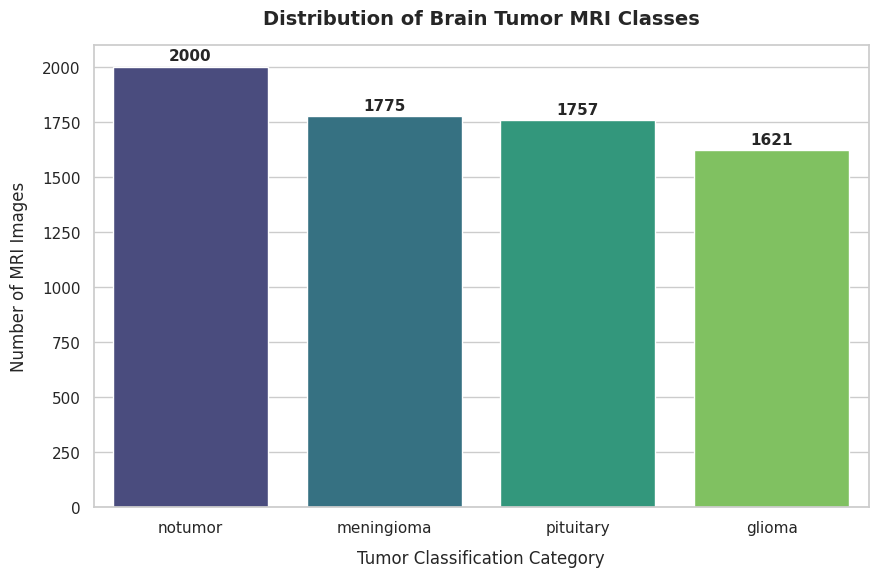

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define dataset path
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

print("--- Starting Class Distribution Analysis ---")

# 1. Extract class names and count images per class
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
class_counts = {}

for class_name in class_names:
    class_dir = dataset_path / class_name
    # Filter valid medical images
    valid_images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    class_counts[class_name] = len(valid_images)

# 2. Create a structured DataFrame and sort by image count (Descending)
df_distribution = pd.DataFrame(list(class_counts.items()), columns=['Class Name', 'Total Images'])
df_distribution['Percentage (%)'] = (df_distribution['Total Images'] / df_distribution['Total Images'].sum()) * 100
df_distribution = df_distribution.sort_values(by='Total Images', ascending=False).reset_index(drop=True)

# 3. Print Class Count Table and Mathematical Imbalance Check
print("\n" + "="*60)
print("📊 CLASS COUNT & DISTRIBUTION TABLE")
print("="*60)
print(df_distribution.to_string(index=False, formatters={'Percentage (%)': '{:.2f}%'.format}))
print("-"*60)

# Calculate Imbalance Ratio (IR) = Max Class Count / Min Class Count
max_images = df_distribution['Total Images'].max()
min_images = df_distribution['Total Images'].min()
imbalance_ratio = max_images / min_images

print("🔍 STATISTICAL DATASET BALANCE CHECK:")
print(f" - Majority Class Count (Max): {max_images} ({df_distribution.loc[df_distribution['Total Images'].idxmax(), 'Class Name']})")
print(f" - Minority Class Count (Min): {min_images} ({df_distribution.loc[df_distribution['Total Images'].idxmin(), 'Class Name']})")
print(f" - Calculated Imbalance Ratio: {imbalance_ratio:.2f}")

# Research standard threshold: IR > 1.5 usually indicates mild to high imbalance
if imbalance_ratio > 1.5:
    print(" - Dataset Status            : DIALECTICALLY IMBALANCED")
    print("   [Recommendation: Consider using class weights or data augmentation during training]")
else:
    print(" - Dataset Status            : WELL-BALANCED")
    print("   [Recommendation: Suitable for standard Cross-Entropy loss training]")
print("="*60)

# 4. Generate and Save Publication-Quality Bar Chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create barplot with sorted order and clear palette
ax = sns.barplot(
    x='Class Name', 
    y='Total Images', 
    data=df_distribution, 
    palette='viridis',
    hue='Class Name',
    legend=False
)

# Add precise value labels on top of each bar without overlapping
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# Configure labels, titles and avoid truncation
plt.title('Distribution of Brain Tumor MRI Classes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tumor Classification Category', fontsize=12, labelpad=10)
plt.ylabel('Number of MRI Images', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Save the figure as a high-DPI image for paper publication
plt.savefig('class_distribution_bar_chart.png', dpi=300, bbox_inches='tight')
print("\n[SUCCESS] Bar chart successfully saved as 'class_distribution_bar_chart.png'")

**Pie chart of dataset classes**

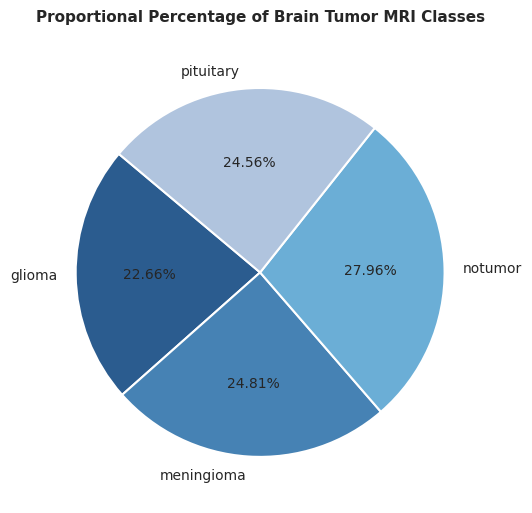


[SUCCESS] Custom compact pie chart saved as 'dataset_classes_pie_chart.png'


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Path Setup
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

# 2. Count images in each class
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
class_counts = {}

for class_name in class_names:
    class_dir = dataset_path / class_name
    valid_images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    class_counts[class_name] = len(valid_images)

# 3. Convert to DataFrame
df_pie = pd.DataFrame(list(class_counts.items()), columns=['Class Name', 'Total Images'])

# 4. Plotting Configuration (Compact Size for Double-Column Papers)
plt.figure(figsize=(5.5, 5.5))  # Reduced size from (8, 8) to (5.5, 5.5)

# High-quality professional medical journal color palette (Muted/Teal/Slate tones)
# These colors look excellent in both digital formats and printouts
professional_colors = ['#2b5c8f', '#4682b4', '#6baed6', '#b0c4de', '#9370db', '#3cb371']
colors = professional_colors[:len(class_names)]

# 5. Create the pie chart
plt.pie(
    df_pie['Total Images'], 
    labels=df_pie['Class Name'], 
    autopct='%1.2f%%',          
    startangle=140,             
    colors=colors,
    textprops={'fontsize': 10, 'fontweight': 'medium'}, # Adjusted font size for compact layout
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True} 
)

# 6. Title Configuration
plt.title('Proportional Percentage of Brain Tumor MRI Classes', fontsize=11, fontweight='bold', pad=15)

# 7. Save as a High-Quality Figure for Publication
output_filename = 'dataset_classes_pie_chart.png'
plt.tight_layout()
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Custom compact pie chart saved as '{output_filename}'")

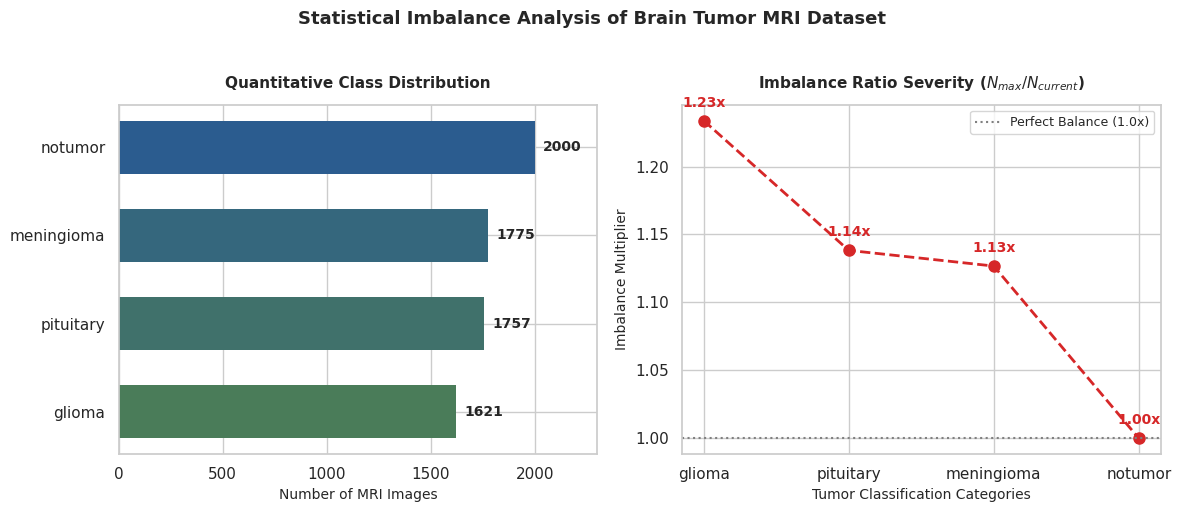


[SUCCESS] Advanced imbalance visualization saved as 'dataset_imbalance_analysis.png'


In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# 1. Path Setup
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

# 2. Count images in each class
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
class_counts = {}

for class_name in class_names:
    class_dir = dataset_path / class_name
    valid_images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    class_counts[class_name] = len(valid_images)

# 3. Process Data for Imbalance Analysis
df_imb = pd.DataFrame(list(class_counts.items()), columns=['Class Name', 'Total Images'])
df_imb = df_imb.sort_values(by='Total Images', ascending=True).reset_index(drop=True)

# Calculate Relative Ratio compared to the Majority Class (Highest Count)
max_count = df_imb['Total Images'].max()
df_imb['Imbalance Ratio (vs Max)'] = max_count / df_imb['Total Images']

# 4. Plotting Configuration (Dual Subplots for Research Paper)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.set_theme(style="whitegrid")

# --- Plot 1: Horizontal Bar Chart (Left) ---
# Fixed: Using matplotlib's LinearSegmentedColormap to avoid Seaborn unpacking error
cmap_custom = LinearSegmentedColormap.from_list("custom_gradient", ["#4a7c59", "#2b5c8f"])
colors_bar = [cmap_custom(i / (len(class_names) - 1)) for i in range(len(class_names))]

bars = ax1.barh(df_imb['Class Name'], df_imb['Total Images'], color=colors_bar, edgecolor='none', height=0.6)

# Add values to the end of horizontal bars
for bar in bars:
    width = bar.get_width()
    ax1.text(width + (max_count * 0.02), bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', 
             va='center', ha='left', fontsize=10, fontweight='bold')

ax1.set_title("Quantitative Class Distribution", fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel("Number of MRI Images", fontsize=10)
ax1.set_xlim(0, max_count * 1.15)

# --- Plot 2: Imbalance Ratio Curve (Right) ---
ax2.plot(df_imb['Class Name'], df_imb['Imbalance Ratio (vs Max)'], 
         color='#d62728', marker='o', linestyle='--', linewidth=2, markersize=8)

# Add ratio values above the markers
for i, txt in enumerate(df_imb['Imbalance Ratio (vs Max)']):
    ax2.annotate(f"{txt:.2f}x", (df_imb['Class Name'][i], df_imb['Imbalance Ratio (vs Max)'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold', color='#d62728')

# Reference line for perfect balance (Ratio = 1.0)
ax2.axhline(y=1.0, color='gray', linestyle=':', label='Perfect Balance (1.0x)')

ax2.set_title("Imbalance Ratio Severity ($N_{max} / N_{current}$)", fontsize=11, fontweight='bold', pad=12)
ax2.set_ylabel("Imbalance Multiplier", fontsize=10)
ax2.set_xlabel("Tumor Classification Categories", fontsize=10)
ax2.legend(loc='upper right', fontsize=9)

# 5. Global Layout Adjustments
plt.suptitle("Statistical Imbalance Analysis of Brain Tumor MRI Dataset", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the figure as a high-DPI image for publication
output_filename = 'dataset_imbalance_analysis.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Advanced imbalance visualization saved as '{output_filename}'")

--- Generating Premium Visuals ---


/tmp/ipykernel_58/3367793728.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_base['Class Name'], fontsize=11, fontweight='medium', color='#34495E')


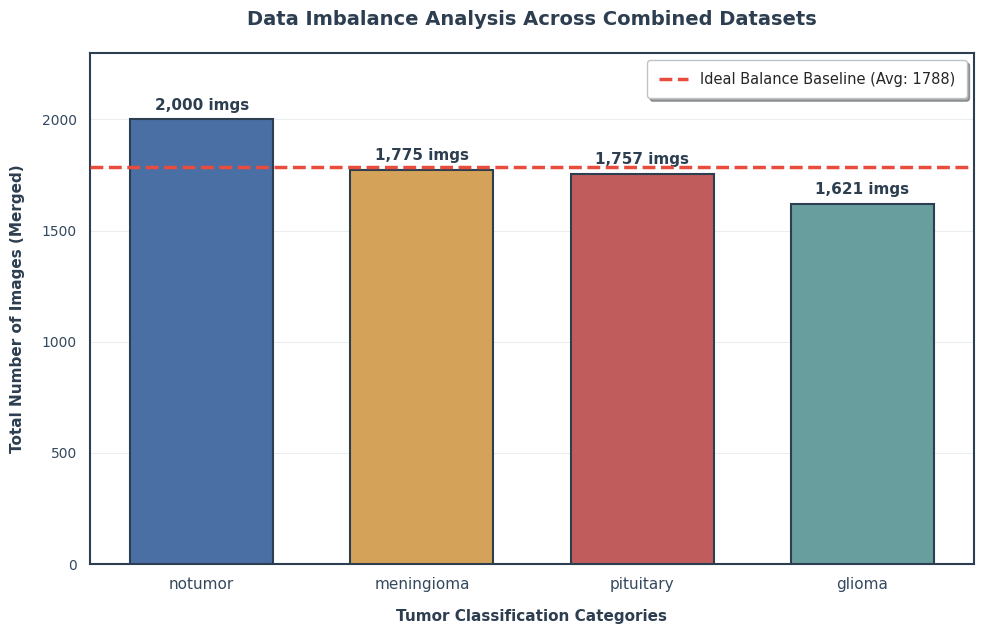

[SUCCESS] Premium chart rendered beautifully and saved as 'premium_imbalance_analysis.png'


In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# 1. Path Setup
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

print("--- Generating Premium Visuals ---")

# 2. Count images in each class
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
class_counts = {}

for class_name in class_names:
    class_dir = dataset_path / class_name
    valid_images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    class_counts[class_name] = len(valid_images)

# 3. Create DataFrame and Calculate Mean
df_base = pd.DataFrame(list(class_counts.items()), columns=['Class Name', 'Total Images'])
df_base = df_base.sort_values(by='Total Images', ascending=False).reset_index(drop=True)
average_images = int(df_base['Total Images'].mean())

# 4. Premium Plotting Configuration
fig, ax = plt.subplots(figsize=(10, 6.5))
sns.set_theme(style="white") # Clean canvas

# Selected Premium Matte Colors matching your screenshot theme
premium_colors = ["#4A6FA5", "#D4A359", "#C05C5C", "#689F9E"]
colors = premium_colors[:len(class_names)]

# Create bars with slight rounded edges effect (via linewidth/joinstyle) and clear borders
bars = ax.bar(
    df_base['Class Name'], 
    df_base['Total Images'], 
    color=colors, 
    edgecolor='#2C3E50', 
    linewidth=1.5,
    width=0.65,
    zorder=3 # Keeps bars above the gridlines
)

# 5. Add a beautiful Ideal Balance Baseline
ax.axhline(
    y=average_images, 
    color='#E74C3C', 
    linestyle='--', 
    linewidth=2.5, 
    label=f'Ideal Balance Baseline (Avg: {average_images})',
    zorder=4
)

# 6. Add Dynamic & Styled Text Labels above bars
max_y_value = df_base['Total Images'].max()
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + (max_y_value * 0.015),
        f'{int(height):,} imgs', # Added comma formatting for thousands
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        color='#2C3E50'
    )

# 7. Fine-tuning Labels, Grid, and Frame (Conference Standard)
ax.set_title('Data Imbalance Analysis Across Combined Datasets', fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
ax.set_xlabel('Tumor Classification Categories', fontsize=11, fontweight='semibold', labelpad=12, color='#2C3E50')
ax.set_ylabel('Total Number of Images (Merged)', fontsize=11, fontweight='semibold', labelpad=12, color='#2C3E50')

# Elegant subtle horizontal gridlines
ax.grid(axis='y', linestyle='-', linewidth=0.7, color='#EAEDED', zorder=0)

# Set limits and ticks configuration
ax.set_ylim(0, max_y_value * 1.15)
ax.set_xticklabels(df_base['Class Name'], fontsize=11, fontweight='medium', color='#34495E')
plt.yticks(fontsize=10, color='#34495E')

# Premium Legend Box Configuration
ax.legend(
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#BDC3C7',
    shadow=True, 
    fontsize=10.5,
    borderpad=0.8
)

# Solid dark frame around the entire plot area
for spine in ax.spines.values():
    spine.set_edgecolor('#2C3E50')
    spine.set_linewidth(1.5)

# 8. Save with High Density Definition
plt.tight_layout()
output_filename = 'premium_imbalance_analysis.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"[SUCCESS] Premium chart rendered beautifully and saved as '{output_filename}'")

Scanning image resolutions (this might take a moment)...
Scan complete! Analyzed 7153 total images.



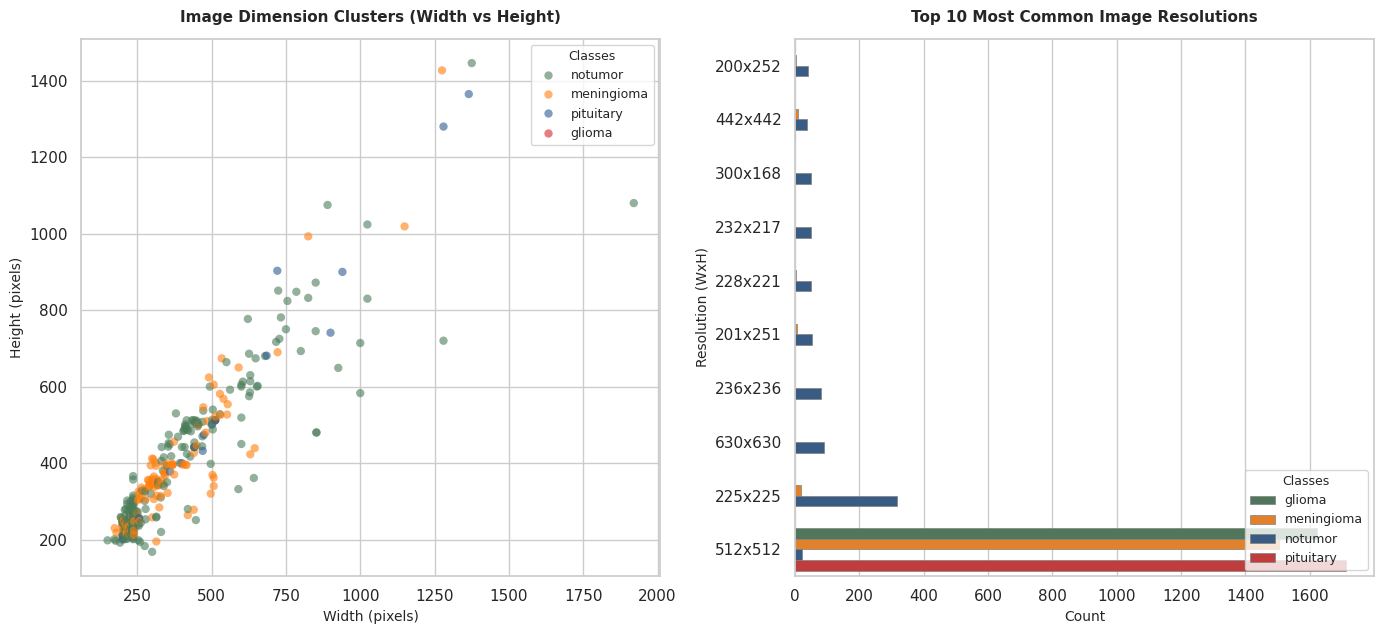

[SUCCESS] Combined resolution chart saved as 'combined_resolution_analysis.png'


In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

# 1. Path Setup
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

print("Scanning image resolutions (this might take a moment)...")

# 2. Extract Dimensions from Images
resolution_data = []
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])

for class_name in class_names:
    class_dir = dataset_path / class_name
    valid_images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    
    for img_path in valid_images:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                resolution_data.append({
                    'Class': class_name,
                    'Width': width,
                    'Height': height,
                    'Resolution': f"{width}x{height}"
                })
        except Exception:
            continue

# 3. Create DataFrame and Calculate Frequencies
df_res = pd.DataFrame(resolution_data)
total_scanned = len(df_res)
print(f"Scan complete! Analyzed {total_scanned} total images.\n")

# Prepare data for Plot 1 (Scatter density mapping)
df_counts = df_res.groupby(['Width', 'Height', 'Class']).size().reset_index(name='Count')

# Prepare data for Plot 2 (Top 10 resolutions sorted)
top10_idx = df_res['Resolution'].value_counts().head(10).index
df_top10 = df_res[df_res['Resolution'].isin(top10_idx)].copy()
# Order them properly for horizontal bar chart display
res_order = list(top10_idx)[::-1] 

# 4. Plotting Side-by-Side Subplots (1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))
sns.set_theme(style="whitegrid")

# Professional Muted Palette for Medical Imaging
journal_palette = ["#4a7c59", "#ff7f0e", "#2b5c8f", "#d62728"]
current_palette = journal_palette[:len(class_names)]

# --- LEFT PLOT: Image Dimension Clusters (Width vs Height) ---
sns.scatterplot(
    data=df_counts,
    x='Width',
    y='Height',
    hue='Class',
    palette=current_palette,
    alpha=0.6,
    edgecolor='none',
    ax=ax1
)
ax1.set_title("Image Dimension Clusters (Width vs Height)", fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel("Width (pixels)", fontsize=10)
ax1.set_ylabel("Height (pixels)", fontsize=10)
ax1.legend(title="Classes", fontsize=9, title_fontsize=9, loc='upper right')

# --- RIGHT PLOT: Top 10 Most Common Image Resolutions ---
sns.countplot(
    data=df_top10,
    y='Resolution',
    hue='Class',
    palette=current_palette,
    order=res_order,
    edgecolor='gray',
    linewidth=0.5,
    ax=ax2
)
ax2.set_title("Top 10 Most Common Image Resolutions", fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel("Count", fontsize=10)
ax2.set_ylabel("Resolution (WxH)", fontsize=10)
ax2.legend(title="Classes", fontsize=9, title_fontsize=9, loc='lower right')

# 5. Global Adjustments and Interactive Forced Rendering
plt.tight_layout()
output_filename = 'combined_resolution_analysis.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"[SUCCESS] Combined resolution chart saved as '{output_filename}'")

In [25]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define paths
DATASET_DIR = '/kaggle/input/datasets/darun04/brgs-comp/BRGS_brain-tumor-mri-dataset'
dataset_path = Path(DATASET_DIR)

# 2. Find all classes and their current counts
class_names = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
class_counts = {}

for class_name in class_names:
    class_dir = dataset_path / class_name
    valid_images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    class_counts[class_name] = len(valid_images)

# Find the maximum number of images in any class (Target Count)
target_count = max(class_counts.values())
print(f"Target count for every class to achieve perfect balance: {target_count}\n")

# 3. Setup Augmentation Generator for minority classes
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 4. Process and balance data into memory
balanced_images = []
balanced_labels = []
IMG_SIZE = (224, 224)

print("--- Balancing Dataset (Please wait...) ---")
for class_idx, class_name in enumerate(class_names):
    class_dir = dataset_path / class_name
    img_paths = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    
    current_count = len(img_paths)
    print(f"Processing '{class_name}': Current = {current_count} -> Target = {target_count}")
    
    # Load all existing original images for this class
    class_images = []
    for p in img_paths:
        img = cv2.imread(str(p))
        if img is not None:
            img = cv2.resize(img, IMG_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            class_images.append(img)
            
            # Add original image and label
            balanced_images.append(img)
            # One-hot encoding representation placeholder or direct index
            balanced_labels.append(class_idx)
            
    class_images = np.array(class_images)
    
    # Calculate how many augmented images are needed
    images_needed = target_count - current_count
    
    if images_needed > 0 and len(class_images) > 0:
        # Generate augmented images to fill the gap
        aug_iter = datagen.flow(class_images, batch_size=1, seed=42)
        for _ in range(images_needed):
            aug_img = next(aug_iter)[0].astype(np.uint8)
            balanced_images.append(aug_img)
            balanced_labels.append(class_idx)

# Convert to numpy arrays
X_balanced = np.array(balanced_images)
y_balanced = np.array(balanced_labels)

print("\n--- Balancing Completed Successfully ---")

# 5. Verify and Print New Balanced Distribution Table
unique, counts = np.unique(y_balanced, return_counts=True)
balanced_distribution = dict(zip([class_names[i] for i in unique], counts))

df_balanced = pd.DataFrame(list(balanced_distribution.items()), columns=['Class Name', 'Total Images (After Balancing)'])
df_balanced['Percentage (%)'] = (df_balanced['Total Images (After Balancing)'] / df_balanced['Total Images (After Balancing)'].sum()) * 100

print("\n" + "="*60)
print("📊 NEW PERFECTLY BALANCED CLASS TABLE")
print("="*60)
print(df_balanced.to_string(index=False, formatters={'Percentage (%)': '{:.2f}%'.format}))
print("="*60)
print(f"Total Balanced Dataset Size: {len(X_balanced)} images")

Target count for every class to achieve perfect balance: 2000

--- Balancing Dataset (Please wait...) ---
Processing 'glioma': Current = 1621 -> Target = 2000
Processing 'meningioma': Current = 1775 -> Target = 2000
Processing 'notumor': Current = 2000 -> Target = 2000
Processing 'pituitary': Current = 1757 -> Target = 2000

--- Balancing Completed Successfully ---

📊 NEW PERFECTLY BALANCED CLASS TABLE
Class Name  Total Images (After Balancing) Percentage (%)
    glioma                            2000         25.00%
meningioma                            2000         25.00%
   notumor                            2000         25.00%
 pituitary                            2000         25.00%
Total Balanced Dataset Size: 8000 images
